# Financial Inclusion — Baseline Model

---

**Goal:** First classification model for predicting `bank_account` (0 = No, 1 = Yes).

**Data source:** `features_encoded_train.csv` — already encoded features from `Train_Encoding.ipynb`

**Important:** Class imbalance — only ~14% of entries have a bank account.  
→ Accuracy is not a meaningful metric. We use **ROC-AUC** as the primary metric.

| Step | Content |
|---|---|
| 1 | Load & understand data |
| 2 | Split X / y |
| 3 | Stratified Train / Validation Split |
| 4 | Baseline: Logistic Regression |
| 5 | Evaluation |
| 6 | Feature Importance |
| 7 | Predictions on test data & submission file |

---
## Step 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)

RANDOM_STATE = 42
print('Imports OK')

Imports OK


---
## Step 1 — Load & understand data

In [2]:
df = pd.read_csv('data/features_encoded_train.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head(3)

Shape: 23,524 rows × 18 columns

Columns: ['age_of_respondent', 'bin_location_type', 'bin_cellphone_access', 'bin_gender', 'ord_education_level', 'ohe_country_Rwanda', 'ohe_country_Tanzania', 'ohe_country_Uganda', 'ohe_job_Farming and Fishing', 'ohe_job_Formally employed Government', 'ohe_job_Formally employed Private', 'ohe_job_Government Dependent', 'ohe_job_Informally employed', 'ohe_job_No Income', 'ohe_job_Other Income', 'ohe_job_Remittance Dependent', 'ohe_job_Self employed', 'target_bank_account']


,age_of_respondent,bin_location_type,bin_cellphone_access,bin_gender,ord_education_level,ohe_country_Rwanda,ohe_country_Tanzania,ohe_country_Uganda,ohe_job_Farming and Fishing,ohe_job_Formally employed Government,ohe_job_Formally employed Private,ohe_job_Government Dependent,ohe_job_Informally employed,ohe_job_No Income,ohe_job_Other Income,ohe_job_Remittance Dependent,ohe_job_Self employed,target_bank_account
0,24,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,1,1
1,70,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,26,1,1,1,3,0,0,0,0,0,0,0,0,0,0,0,1,1


Target distribution (target_bank_account):
  No  (0): 20,212  (85.9%)
  Yes (1): 3,312  (14.1%)

→ Class imbalance! We use class_weight="balanced" and ROC-AUC as metric.


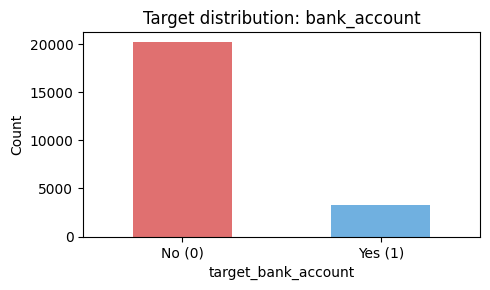

In [3]:
# Check class distribution
vc = df['target_bank_account'].value_counts()
print('Target distribution (target_bank_account):')
print(f'  No  (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'  Yes (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print()
print('→ Class imbalance! We use class_weight="balanced" and ROC-AUC as metric.')

fig, ax = plt.subplots(figsize=(5, 3))
vc.rename({0: 'No (0)', 1: 'Yes (1)'}).plot(kind='bar', ax=ax, color=['#e07070', '#70b0e0'])
ax.set_title('Target distribution: bank_account')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

---
## Step 2 — Split X / y

In [4]:
X = df.drop(columns=['target_bank_account'])
y = df['target_bank_account']

print(f'X shape: {X.shape}  (Features)')
print(f'y shape: {y.shape}  (Target)')
print(f'\nFeature columns ({len(X.columns)}):')
for col in X.columns:
    print(f'  • {col}')

X shape: (23524, 17)  (Features)
y shape: (23524,)  (Target)

Feature columns (17):
  • age_of_respondent
  • bin_location_type
  • bin_cellphone_access
  • bin_gender
  • ord_education_level
  • ohe_country_Rwanda
  • ohe_country_Tanzania
  • ohe_country_Uganda
  • ohe_job_Farming and Fishing
  • ohe_job_Formally employed Government
  • ohe_job_Formally employed Private
  • ohe_job_Government Dependent
  • ohe_job_Informally employed
  • ohe_job_No Income
  • ohe_job_Other Income
  • ohe_job_Remittance Dependent
  • ohe_job_Self employed


---
## Step 3 — Stratified Train / Validation Split

**Stratified** ensures that the class distribution (14% Yes) is equal in both splits.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # important due to class imbalance
)

print(f'Train set : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Val set   : {X_val.shape[0]:,} rows  ({X_val.shape[0]/len(X)*100:.0f}%)')
print()
print('Class distribution in y_train:')
print(y_train.value_counts(normalize=True).round(3))
print('Class distribution in y_val:')
print(y_val.value_counts(normalize=True).round(3))

Train set : 18,819 rows  (80%)
Val set   : 4,705 rows  (20%)

Class distribution in y_train:
target_bank_account
0    0.859
1    0.141
Name: proportion, dtype: float64
Class distribution in y_val:
target_bank_account
0    0.859
1    0.141
Name: proportion, dtype: float64


---
## Step 4 — Baseline: Logistic Regression

**Why Logistic Regression as baseline?**
- Fast and interpretable
- Outputs probabilities (required for ROC-AUC)
- `class_weight='balanced'` automatically compensates for class imbalance
- Serves as a reference point for more complex models

In [6]:
model = LogisticRegression(
    class_weight='balanced',    # compensates 86/14 split
    max_iter=1000,              # enough iterations for convergence
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)
print('Model trained.')

Model trained.


---
## Step 5 — Evaluation

In [7]:
# Predictions
y_pred       = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]  # probability for class 1

# ROC-AUC (primary metric)
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f'ROC-AUC (Validation): {roc_auc:.4f}')
print()

# Classification Report
print('Classification Report:')
print(classification_report(y_val, y_pred, target_names=['No (0)', 'Yes (1)']))

ROC-AUC (Validation): 0.8574

Classification Report:
              precision    recall  f1-score   support

      No (0)       0.95      0.78      0.86      4043
     Yes (1)       0.36      0.76      0.49       662

    accuracy                           0.78      4705
   macro avg       0.66      0.77      0.68      4705
weighted avg       0.87      0.78      0.81      4705



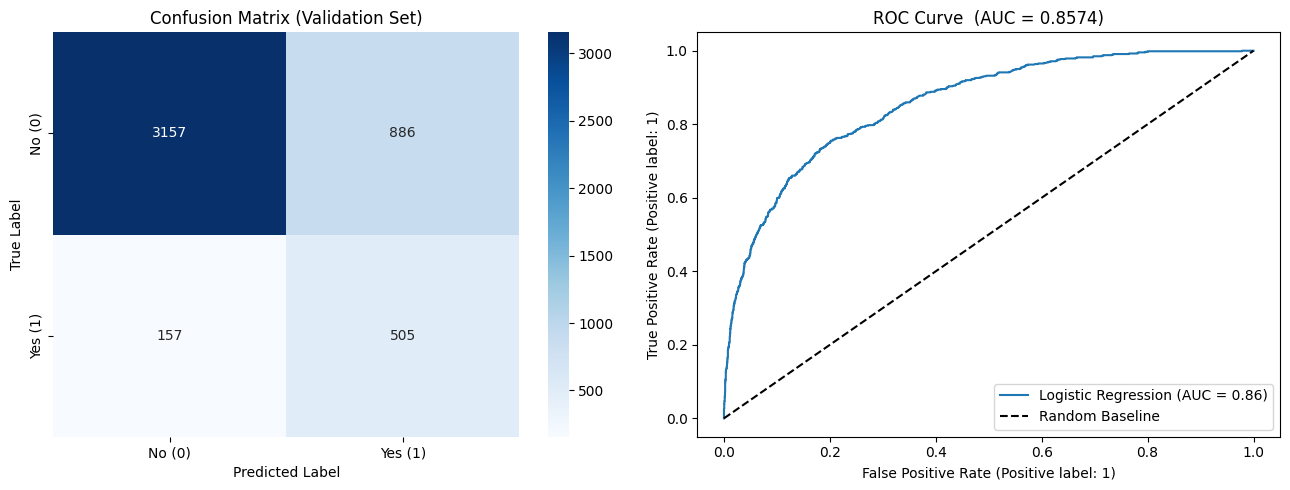

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['No (0)', 'Yes (1)'],
    yticklabels=['No (0)', 'Yes (1)']
)
axes[0].set_title('Confusion Matrix (Validation Set)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_val, y_pred_proba, ax=axes[1], name='Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[1].set_title(f'ROC Curve  (AUC = {roc_auc:.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 6 — Feature Importance (Coefficients)

In Logistic Regression the magnitude of the coefficient shows how strongly a feature contributes to the decision.  
Positive = increases the probability of "Yes", negative = decreases it.

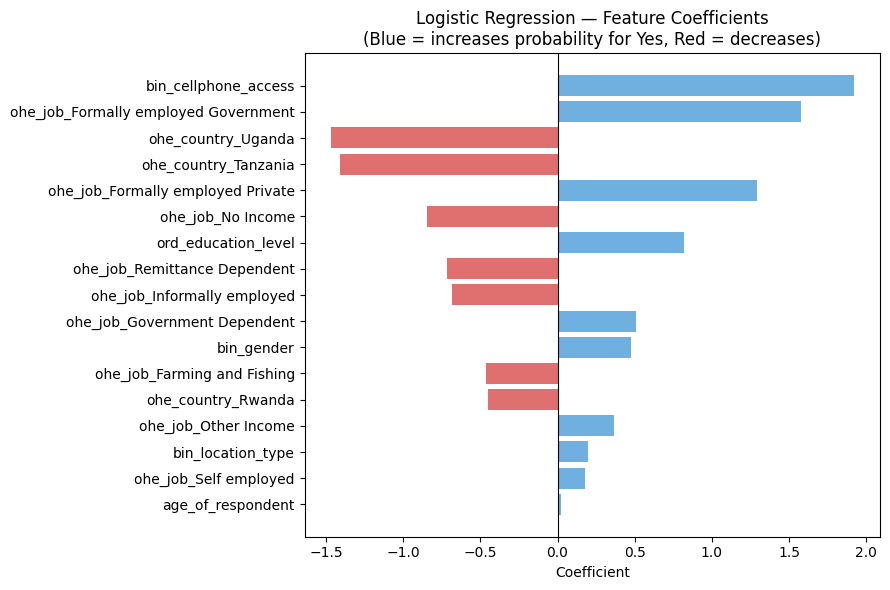

Top 5 most important features:
                             feature  coefficient
                bin_cellphone_access     1.918934
ohe_job_Formally employed Government     1.574691
                  ohe_country_Uganda    -1.468356
                ohe_country_Tanzania    -1.405311
   ohe_job_Formally employed Private     1.293795


In [9]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e07070' if c < 0 else '#70b0e0' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients\n(Blue = increases probability for Yes, Red = decreases)')
ax.set_xlabel('Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(coef_df.head(5).to_string(index=False))

---
## Step 7 — Predictions on Test Data & Submission File

The submission expects **33,610 rows** — Train (23,524) + Test (10,086).  
Format of the ID: `uniqueid + ' x ' + country`

Process:
1. Retrain model on **all** training data (no 80/20 split)
2. Predictions for Train rows (known data) + Test rows
3. Build IDs and fill submission file

In [10]:
# Retrain model on ALL training data (not just 80%)
model_full = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model_full.fit(X, y)
print('Model trained on full training data.')

# Predictions for Train rows
train_proba = model_full.predict_proba(X)[:, 1]

# Predictions for Test rows
X_test = pd.read_csv('data/features_encoded_TEST.csv')
test_proba = model_full.predict_proba(X_test)[:, 1]

print(f'Train predictions: {len(train_proba):,}')
print(f'Test  predictions: {len(test_proba):,}')

Model trained on full training data.
Train predictions: 23,524
Test  predictions: 10,086


In [11]:
# Get IDs from original data: format "uniqueid x country"
train_raw = pd.read_csv('data/Train.csv')[['uniqueid', 'country']]
test_raw  = pd.read_csv('data/Test.csv')[['uniqueid', 'country']]

train_raw['unique_id'] = train_raw['uniqueid'] + ' x ' + train_raw['country']
test_raw['unique_id']  = test_raw['uniqueid']  + ' x ' + test_raw['country']

# Build DataFrames with predictions
df_train_pred = pd.DataFrame({'unique_id': train_raw['unique_id'].values, 'bank_account': train_proba})
df_test_pred  = pd.DataFrame({'unique_id': test_raw['unique_id'].values,  'bank_account': test_proba})

# Mergeenführen
all_preds = pd.concat([df_train_pred, df_test_pred], ignore_index=True)
print(f'Gesamt-Predictions: {len(all_preds):,}')
all_preds.head(3)

Gesamt-Predictions: 33,610


,unique_id,bank_account
0,uniqueid_1 x Kenya,0.696520
1,uniqueid_2 x Kenya,0.292496
2,uniqueid_3 x Kenya,0.917730


In [12]:
# Keep row order from SampleSubmission
submission = pd.read_csv('data/SampleSubmission.csv')
submission = submission.drop(columns=['bank_account']).merge(all_preds, on='unique_id', how='left')

assert len(submission) == 33610, f'Row count wrong: {len(submission)}'
assert submission['bank_account'].isnull().sum() == 0, 'NaN in predictions!'

output_path = 'submission_baseline_logreg.csv'
submission.to_csv(output_path, index=False)

print(f'Submission saved: {output_path}')
print(f'Rows: {len(submission):,}')
print(f'Prediction-Range: {submission["bank_account"].min():.4f} – {submission["bank_account"].max():.4f}')
submission.head()

Submission saved: submission_baseline_logreg.csv
Rows: 33,610
Prediction-Range: 0.0054 – 0.9955


,unique_id,bank_account
0,uniqueid_1 x Kenya,0.696520
1,uniqueid_2 x Kenya,0.292496
2,uniqueid_3 x Kenya,0.917730
3,uniqueid_4 x Kenya,0.810459
4,uniqueid_5 x Kenya,0.119213


---
## Summary & Next Steps

### Baseline Results (Logistic Regression)

| Metric | Value |
|---|---|
| ROC-AUC (Validation) | *see above* |

### Next Steps

| Model | Advantage | Next Notebook |
|---|---|---|
| Random Forest | Robust, Feature Importance, no scaling needed | `Model_RandomForest.ipynb` |
| LightGBM | Fast, strong on tabular data | `Model_LightGBM.ipynb` |
| XGBoost | Often best performance for classification | `Model_XGBoost.ipynb` |

**Possible improvements:**
- Tune `class_weight` / `scale_pos_weight`
- Hyperparameter search (GridSearchCV)
- Try tree-based models for non-linear patterns